<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/10_bonus_pandas_tricks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[⬅ Back to the course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 10 of the course**


# 🩺 Notebook 10 — 30 pandas tricks for medical researchers

> A fast, punchy grab-bag. Thirty small pandas moves that turn a wall of ICU data into an answer
> in one line. Steal them, keep them, use them on your own datasets. No modelling here — just the
> *craft* of wrangling clinical tables quickly and correctly.

**What you'll learn**
- 30 numbered, copy-paste-ready pandas idioms, each demonstrated on the real sepsis ICU data
- How to **select, filter, reshape, summarise and time-shift** clinical tables in one readable line
- Time-series-safe patterns (`groupby` + `shift`/`diff`/`rolling`/`cumsum`) that respect patient boundaries
- Little presentation wins: **binning ages, styled tables, and shrinking memory**

**⏱️ Time:** ≈40 min · **Prerequisites:** none — dip in any time (Notebooks 01–04 give more depth)

Each trick is **one short explanation + one runnable cell**. Run them top to bottom, then cherry-pick your favourites.

## ⚙️ Run me first

Run the setup cell below once. It installs anything missing, sets a clean plot style, and defines the
data loaders (`load_csv`, `load_patients`). Then we load both tables.

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )


In [2]:
def build_patient_table(ts):
    """Aggregate the 4-hourly time-series into ONE row per ICU stay.
       (This is exactly what Notebook 04 teaches you to build.)"""
    df = ts.copy()
    # clean temperature: prefer Celsius; repair obvious Fahrenheit-entry errors; drop impossible
    tf = df["Temp_F"].where((df["Temp_F"] >= 90) & (df["Temp_F"] <= 110))
    tc = df["Temp_C"].where((df["Temp_C"] >= 25) & (df["Temp_C"] <= 45))
    df["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)
    # impossible vitals -> NaN, then forward/back-fill WITHIN each stay
    for c, lo, hi in [("HR",20,300),("SysBP",40,300),("MeanBP",20,220),("RR",3,80),("SpO2",30,100)]:
        df[c] = df[c].where((df[c] >= lo) & (df[c] <= hi))
    g = df.groupby("icustayid", group_keys=False)
    vit = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean"]
    df[vit] = g[vit].apply(lambda x: x.ffill().bfill())
    # winsorise skewed labs so one stray value can't define a min/max
    for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","INR","Glucose"]:
        lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
        df[c] = df[c].clip(lo, hi)
    tv = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean","GCS","Creatinine","BUN",
          "Arterial_lactate","WBC_count","Platelets_count","Potassium","Sodium",
          "Albumin","INR","Arterial_pH","Shock_Index","SOFA","SIRS","PaO2_FiO2","Hb"]
    grp = df.groupby("icustayid")
    f = {}
    f["age"]=grp["age"].first(); f["gender"]=grp["gender"].first()
    f["elixhauser"]=grp["elixhauser"].first(); f["re_admission"]=grp["re_admission"].first().astype(int)
    f["weight_kg"]=grp["Weight_kg"].median(); f["n_blocs"]=grp.size(); f["los_hours"]=grp["bloc"].max()*4
    f["mechvent_ever"]=grp["mechvent"].max(); f["vaso_max"]=grp["max_dose_vaso"].max()
    f["fluid_balance_last"]=grp["cumulated_balance"].last(); f["urine_total"]=grp["output_step"].sum()
    for c in tv:
        f[f"{c}_mean"]=grp[c].mean(); f[f"{c}_min"]=grp[c].min()
        f[f"{c}_max"]=grp[c].max();  f[f"{c}_last"]=grp[c].last()
    for c in ["Creatinine","Arterial_lactate","SOFA","Shock_Index","GCS"]:
        f[f"{c}_delta"]=grp[c].last()-grp[c].first()
    X = pd.DataFrame(f); X["morta_90"]=grp["morta_90"].max(); X["died_in_hosp"]=grp["died_in_hosp"].max()
    return X.reset_index()

def load_patients():
    p = _find("sepsis_patients.csv")
    if p:
        print(f"✓ loaded {p}"); return pd.read_csv(p)
    print("sepsis_patients.csv not found — building it from the time-series file…")
    return build_patient_table(load_csv("sepsis_timeseries.csv"))

In [3]:
# Load both tables. `df` = time-series (1 row per patient per 4h block); `patients` = 1 row per stay.
df = load_csv("sepsis_timeseries.csv")
patients = load_patients()
df = df.sort_values(["icustayid", "bloc"]).reset_index(drop=True)   # tidy order for the time-series tricks
print("time-series:", df.shape, " | patients:", patients.shape)

✓ loaded data/sepsis_timeseries.csv
✓ loaded data/sepsis_patients.csv
time-series: (37704, 53)  | patients: (1696, 107)


---
## 🔎 Theme 1 — Selecting & filtering (tricks 1–7)

The bread and butter: getting exactly the rows and columns you want.

### 1 · `.loc` vs `.iloc` — label vs position

`.iloc` selects by **integer position** (like a spreadsheet cell reference). `.loc` selects by
**label** — column names and boolean masks. When in doubt for clinical work, reach for `.loc`.

In [4]:
# .iloc  → first 3 rows, first 5 columns (by POSITION)
display(df.iloc[0:3, 0:5])

# .loc   → rows where age > 80, and only the columns we name (by LABEL)
display(df.loc[df["age"] > 80, ["icustayid", "bloc", "age", "SOFA", "Arterial_lactate"]].head())

,icustayid,bloc,timestep,age,gender
0,30003226,1,4833101040,67,0
1,30003226,2,4833115440,67,0
2,30003226,3,4833129840,67,0


,icustayid,bloc,age,SOFA,Arterial_lactate
71,30023732,1,89,8,2.4
72,30023732,2,89,11,2.7
73,30023732,3,89,8,2.7
74,30023732,4,89,6,2.7
75,30023732,5,89,3,2.7


### 2 · `.query()` — filter with a readable sentence

`.query("...")` lets you write the filter as plain text instead of stacking brackets. Reference an
outside variable with `@`.

In [5]:
lac_cut = 4.0
hits = df.query("age > 65 and Arterial_lactate > @lac_cut")
print(f"{len(hits):,} block-rows: patients >65 with lactate > {lac_cut}")
hits[["icustayid", "age", "Arterial_lactate", "MeanBP", "SOFA"]].head()

988 block-rows: patients >65 with lactate > 4.0


,icustayid,age,Arterial_lactate,MeanBP,SOFA
207,30031362,83,4.50,80.10,1
405,30055897,91,4.40,52.80,6
848,30207861,74,8.25,96.47,5
849,30207861,74,6.42,106.80,4
850,30207861,74,5.16,108.60,3


### 3 · `.isin()` — match against a list

Pull every row for a specific set of patients (or lab values) without writing a chain of `or`s.

In [6]:
some_ids = df["icustayid"].unique()[:3]           # three example stays
df[df["icustayid"].isin(some_ids)][["icustayid", "bloc", "HR", "MeanBP"]].head(9)

,icustayid,bloc,HR,MeanBP
0,30003226,1,83.40,88.00
1,30003226,2,69.71,87.29
2,30003226,3,66.25,101.50
3,30003226,4,72.12,87.25
4,30003226,5,75.25,104.12
5,30003226,6,64.43,106.86
6,30003226,7,75.00,95.75
7,30003226,8,69.20,96.00
8,30003226,9,64.00,95.17


### 4 · `.between()` — inside a range in one call

Great for "is this vital in the normal band?". `between(lo, hi)` is inclusive on both ends.

In [7]:
normal_hr = df["HR"].between(60, 100)
print(f"{normal_hr.mean():.1%} of blocks have a heart rate in the normal 60–100 range")
df.loc[normal_hr, ["icustayid", "bloc", "HR"]].head()

77.4% of blocks have a heart rate in the normal 60–100 range


,icustayid,bloc,HR
0,30003226,1,83.40
1,30003226,2,69.71
2,30003226,3,66.25
3,30003226,4,72.12
4,30003226,5,75.25


### 5 · Combining boolean masks — `&`, `|`, `~`

Build a filter from several conditions. **Each condition needs its own parentheses**, and use
`&`/`|`/`~` (not `and`/`or`/`not`). Here: septic shock proxy = low MAP **and** high lactate.

In [8]:
shock = (df["MeanBP"] < 65) & (df["Arterial_lactate"] > 2)
print(f"{shock.sum():,} blocks look like septic shock (MAP<65 & lactate>2)")
df.loc[shock, ["icustayid", "bloc", "MeanBP", "Arterial_lactate", "max_dose_vaso"]].head()

1,157 blocks look like septic shock (MAP<65 & lactate>2)


,icustayid,bloc,MeanBP,Arterial_lactate,max_dose_vaso
405,30055897,50,52.80,4.40,0.00
411,30055897,56,64.60,2.10,0.00
448,30082614,2,56.50,14.85,0.35
449,30082614,3,57.56,13.57,0.40
450,30082614,4,58.36,10.62,0.40


### 6 · `.nlargest()` / `.nsmallest()` — top-N without sorting the whole table

Faster and clearer than `sort_values(...).head()`. Who had the sickest single lactate reading?

In [9]:
df.nlargest(5, "Arterial_lactate")[["icustayid", "bloc", "Arterial_lactate", "MeanBP", "SOFA"]]

,icustayid,bloc,Arterial_lactate,MeanBP,SOFA
19711,35054910,10,20.2,97.78,0
19712,35054910,11,20.2,102.86,0
19713,35054910,12,20.2,96.00,0
19715,35054910,14,20.2,96.12,0
19719,35054910,18,20.2,93.40,0


### 7 · `.sample()` — a reproducible random peek

`random_state` makes it repeatable — essential for anything you'll put in a paper. Use `frac=` for a
percentage instead of a count.

In [10]:
df.sample(5, random_state=RANDOM_STATE)[["icustayid", "bloc", "age", "HR", "SOFA", "morta_90"]]

,icustayid,bloc,age,HR,SOFA,morta_90
6972,31719089,10,54,62.75,2,0
21459,35499196,43,57,79.67,10,1
2116,30538768,2,72,77.53,5,0
5211,31313696,5,28,82.25,4,0
4660,31150594,45,48,114.25,8,0


> 🧠 **Clinical takeaway:** `.loc` + boolean masks is how you build every cohort definition
> ("adults with lactate > 2 on vasopressors"). Master this and half of data wrangling is done.

### ✏️ Your turn #1
Count the block-rows for patients **aged 18–50** (inclusive) whose **`SOFA` is 10 or higher**, and
show the first few with `icustayid, age, SOFA, Arterial_lactate`.

In [11]:
# TODO: use .between() for age and a boolean mask for SOFA >= 10, then combine with &


<details><summary>💡 Show solution</summary>

```python
mask = df["age"].between(18, 50) & (df["SOFA"] >= 10)
print(f"{mask.sum():,} block-rows")
df.loc[mask, ["icustayid", "age", "SOFA", "Arterial_lactate"]].head()
```
</details>

---
## 🛠️ Theme 2 — Creating & transforming columns (tricks 8–14)

### 8 · `.assign()` — add columns without breaking the chain

`.assign()` returns a new frame with extra columns, so you can keep chaining. Use a `lambda` to refer
to columns you just made.

In [12]:
(df.assign(
        MAP_est     = lambda d: d["DiaBP"] + (d["SysBP"] - d["DiaBP"]) / 3,   # estimated mean arterial pressure
        hypotensive = lambda d: d["MeanBP"] < 65,
    )[["icustayid", "SysBP", "DiaBP", "MAP_est", "MeanBP", "hypotensive"]]
    .head())

,icustayid,SysBP,DiaBP,MAP_est,MeanBP,hypotensive
0,30003226,141.75,61.12,87.996667,88.00,False
1,30003226,147.86,57.00,87.286667,87.29,False
2,30003226,169.50,67.50,101.500000,101.50,False
3,30003226,145.50,48.75,81.000000,87.25,False
4,30003226,134.00,32.00,66.000000,104.12,False


### 9 · `.pipe()` — chain your OWN functions

`.pipe(fn)` slots a custom function into a chain, keeping everything left-to-right and readable.

In [13]:
def add_pulse_pressure(d):
    return d.assign(PulsePressure=d["SysBP"] - d["DiaBP"])

def flag_shock(d):
    return d.assign(is_shock=d["Shock_Index"] > 0.9)

out = df.pipe(add_pulse_pressure).pipe(flag_shock)
out[["icustayid", "SysBP", "DiaBP", "PulsePressure", "Shock_Index", "is_shock"]].head()

,icustayid,SysBP,DiaBP,PulsePressure,Shock_Index,is_shock
0,30003226,141.75,61.12,80.63,0.59,False
1,30003226,147.86,57.00,90.86,0.47,False
2,30003226,169.50,67.50,102.00,0.39,False
3,30003226,145.50,48.75,96.75,0.50,False
4,30003226,134.00,32.00,102.00,0.56,False


### 10 · `.map()` / `.replace()` — recode values

`Series.map({...})` swaps coded values for readable labels (use `.map`, not the removed `applymap`).
`.replace` does the same and can take multiple columns.

In [14]:
outcome_lbl = df["morta_90"].map({0: "survived", 1: "died"})
readmit_lbl = df["re_admission"].replace({True: "re-admission", False: "first stay"})
pd.DataFrame({"morta_90": df["morta_90"], "outcome": outcome_lbl, "re_admission": readmit_lbl}).head()

,morta_90,outcome,re_admission
0,0,survived,first stay
1,0,survived,first stay
2,0,survived,first stay
3,0,survived,first stay
4,0,survived,first stay


### 11 · `.clip()` — winsorise extreme values

Cap absurd outliers at sensible percentiles **without deleting the patient**. Never clip the *label* —
only features.

In [15]:
q01, q99 = df["Creatinine"].quantile([0.01, 0.99])
clipped = df["Creatinine"].clip(lower=q01, upper=q99)
pd.DataFrame({"raw": df["Creatinine"].describe(), "clipped": clipped.describe()}).round(2)

,raw,clipped
count,37704.00,37704.00
mean,1.82,1.77
std,2.33,1.94
min,0.00,0.30
25%,0.70,0.70
50%,1.07,1.07
75%,1.90,1.90
max,74.96,12.44


### 12 · `pd.cut()` — bin a continuous variable into clinical categories

Turn age into **age bands** (or lactate into normal/elevated/high). You choose the edges. `right=False`
makes bins left-closed like `[45, 55)`.

In [16]:
bins   = [0, 45, 55, 65, 75, 120]
labels = ["<45", "45–54", "55–64", "65–74", "75+"]
patients["age_band"] = pd.cut(patients["age"], bins=bins, labels=labels, right=False)
patients["age_band"].value_counts().sort_index()

age_band
<45      176
45–54    200
55–64    356
65–74    411
75+      553
Name: count, dtype: int64

### 13 · `pd.qcut()` — bin into *equal-sized* groups (quantiles)

`cut` uses value edges you pick; **`qcut` uses quantiles** so each bin has roughly equal N. Perfect for
a dose-response look: does peak lactate quartile track mortality?

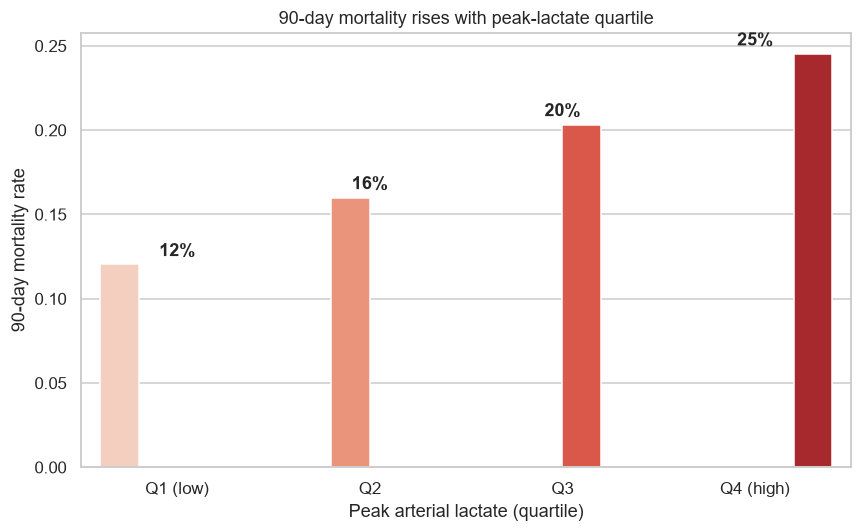

In [17]:
patients["lactate_q"] = pd.qcut(patients["Arterial_lactate_max"], q=4,
                                labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
mort_by_q = patients.groupby("lactate_q", observed=True)["morta_90"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=mort_by_q.index, y=mort_by_q.values, hue=mort_by_q.index,
            palette="Reds", legend=False, ax=ax)
for i, v in enumerate(mort_by_q.values):
    ax.text(i, v + 0.005, f"{v:.0%}", ha="center", fontweight="bold")
ax.set(title="90-day mortality rises with peak-lactate quartile",
       xlabel="Peak arterial lactate (quartile)", ylabel="90-day mortality rate")
plt.tight_layout(); plt.show()

*Interpretation:* mortality climbs monotonically across lactate quartiles — a textbook
dose-response signal that `qcut` surfaces in two lines.

### 14 · `.rank()` — turn values into ranks / percentiles

`rank(pct=True)` gives each patient's percentile on a score — handy for "top 10% sickest".

In [18]:
patients["sofa_pct"] = patients["SOFA_max"].rank(pct=True)
patients.nlargest(5, "SOFA_max")[["icustayid", "SOFA_max", "sofa_pct", "morta_90"]].round(3)

,icustayid,SOFA_max,sofa_pct,morta_90
21,30082614,17,0.999,1
285,31593624,17,0.999,0
964,35541349,17,0.999,0
136,30794450,16,0.998,1
458,32614649,16,0.998,0


> 🧠 **Clinical takeaway:** binning (`cut`/`qcut`) is how you present risk to colleagues —
> quartiles and age bands are far easier to read in a table than raw continuous numbers.

---
## 📊 Theme 3 — Summarising & counting (tricks 15–20)

### 15 · `.value_counts(normalize=True)` — proportions, not just counts

Add `normalize=True` for fractions. This is your one-liner for **class balance** and prevalence.

In [19]:
print("90-day mortality (per patient):")
print(patients["morta_90"].value_counts(normalize=True).rename({0: "survived", 1: "died"}).round(3))
print("\nSOFA distribution (top values, time-series):")
print(df["SOFA"].value_counts(normalize=True).sort_index().head())

90-day mortality (per patient):
morta_90
survived    0.818
died        0.182
Name: proportion, dtype: float64

SOFA distribution (top values, time-series):
SOFA
0    0.066120
1    0.073414
2    0.103490
3    0.136856
4    0.134734
Name: proportion, dtype: float64


### 16 · `.nunique()` — how many distinct things?

Count unique patients, or spot near-constant columns.

In [20]:
print("unique ICU stays :", df["icustayid"].nunique())
print("distinct blocs   :", df["bloc"].nunique())
print("\nColumns with the FEWEST distinct values (often flags/labels):")
print(df.nunique().sort_values().head(8))

unique ICU stays : 1696
distinct blocs   : 68

Columns with the FEWEST distinct values (often flags/labels):
gender           2
re_admission     2
morta_90         2
mechvent         2
died_in_hosp     2
SIRS             5
elixhauser      14
SOFA            18
dtype: int64


### 17 · `pd.crosstab()` — a contingency table in one call

Cross two categoricals; `normalize="index"` gives row-wise rates. Here: mortality rate by age band.

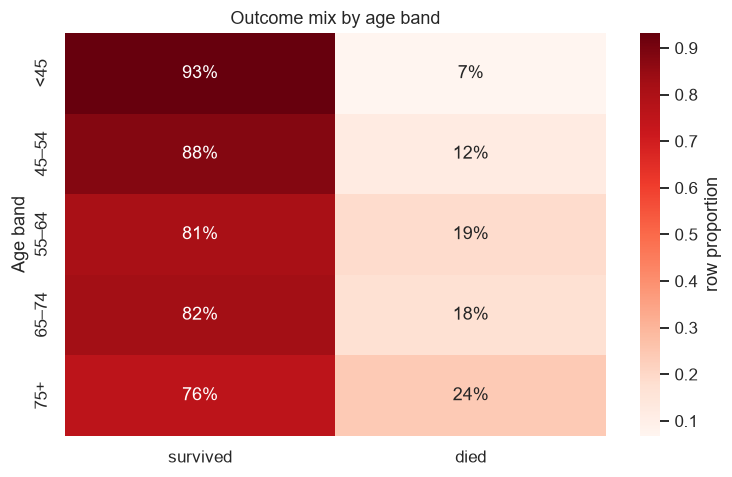

In [21]:
ct = pd.crosstab(patients["age_band"], patients["morta_90"], normalize="index")
ct.columns = ["survived", "died"]

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(ct, annot=True, fmt=".0%", cmap="Reds", cbar_kws={"label": "row proportion"}, ax=ax)
ax.set(title="Outcome mix by age band", xlabel="", ylabel="Age band")
plt.tight_layout(); plt.show()

### 18 · `.duplicated()` — find (and drop) repeated rows

This dataset has **6 exact-duplicate rows injected on purpose**. `duplicated()` finds them; pass a
`subset` to check a *key* like `(icustayid, bloc)`.

In [22]:
print("exact duplicate rows      :", df.duplicated().sum())
print("duplicate (icustayid,bloc) :", df.duplicated(subset=["icustayid", "bloc"]).sum())
df_dedup = df.drop_duplicates()
print("rows before / after         :", len(df), "/", len(df_dedup))

exact duplicate rows      : 6
duplicate (icustayid,bloc) : 6
rows before / after         : 37704 / 37698


### 19 · `groupby().agg()` with **named aggregation**

The clearest way to build a per-patient summary: `new_name=("column", "func")`. Self-documenting output
columns.

In [23]:
summary = (df.groupby("icustayid")
             .agg(n_blocs      = ("bloc", "size"),
                  max_sofa     = ("SOFA", "max"),
                  mean_hr      = ("HR", "mean"),
                  peak_lactate = ("Arterial_lactate", "max"),
                  died         = ("morta_90", "max"))
             .round(1))
summary.head()

,n_blocs,max_sofa,mean_hr,peak_lactate,died
icustayid,,,,,
30003226,12,7,73.3,2.0,0
30004576,7,5,95.7,3.3,0
30004811,14,8,83.1,3.0,0
30009596,9,8,60.8,2.8,0
30011748,5,3,71.1,2.4,0


### 20 · `groupby().transform()` — a group statistic, broadcast back to every row

Unlike `agg` (which collapses), `transform` returns the **same shape**, so you can compare each block to
its patient's own average.

In [24]:
df["HR_pt_mean"]  = df.groupby("icustayid")["HR"].transform("mean")
df["HR_centered"]  = df["HR"] - df["HR_pt_mean"]     # this block vs THIS patient's baseline
df[["icustayid", "bloc", "HR", "HR_pt_mean", "HR_centered"]].head()

,icustayid,bloc,HR,HR_pt_mean,HR_centered
0,30003226,1,83.40,73.310833,10.089167
1,30003226,2,69.71,73.310833,-3.600833
2,30003226,3,66.25,73.310833,-7.060833
3,30003226,4,72.12,73.310833,-1.190833
4,30003226,5,75.25,73.310833,1.939167


> 🧠 **Clinical takeaway:** `transform` is the trick for **per-patient baselines** — "is this HR high
> *for this patient*?" is often more informative than a population threshold.

### ✏️ Your turn #2
Build a per-patient summary with **named aggregation**: number of blocks (`n`), **mean MAP**
(`mean_map` from `MeanBP`), **min SpO2** (`worst_spo2`), and whether they **ever received a
vasopressor** (`any_vaso` = max of `max_dose_vaso` > 0).

In [25]:
# TODO: df.groupby("icustayid").agg(  n=..., mean_map=..., worst_spo2=..., max_vaso=... )
#       then derive any_vaso from max_vaso


<details><summary>💡 Show solution</summary>

```python
s = (df.groupby("icustayid")
       .agg(n=("bloc", "size"),
            mean_map=("MeanBP", "mean"),
            worst_spo2=("SpO2", "min"),
            max_vaso=("max_dose_vaso", "max")))
s["any_vaso"] = s["max_vaso"] > 0
s.head()
```
</details>

---
## 🔄 Theme 4 — Reshaping & combining (tricks 21–24)

### 21 · `pivot_table()` — spreadsheet-style cross-summaries

Average a value across two dimensions. Here: mean lactate at each time-block, split by outcome — you can
watch survivors and non-survivors diverge.

In [26]:
pt = df.pivot_table(index="bloc", columns="morta_90", values="Arterial_lactate", aggfunc="mean")
pt.columns = ["survived", "died"]
pt.head(8).round(2)

,survived,died
bloc,,
1,1.99,2.22
2,1.96,2.29
3,1.88,2.31
4,1.84,2.29
5,1.79,2.19
6,1.78,2.16
7,1.76,2.02
8,1.69,2.15


### 22 · `.melt()` — wide → long (tidy) format

Seaborn and many models like **long** data. `melt` stacks several columns into `variable`/`value` pairs.

In [27]:
sub = patients[["icustayid", "HR_max", "SysBP_max", "RR_max"]].head()
long = sub.melt(id_vars="icustayid", var_name="feature", value_name="value")
long

,icustayid,feature,value
0,30003226,HR_max,84.20
1,30004576,HR_max,108.33
2,30004811,HR_max,96.00
3,30009596,HR_max,83.89
4,30011748,HR_max,75.12
5,30003226,SysBP_max,169.50
6,30004576,SysBP_max,138.83
7,30004811,SysBP_max,127.75
8,30009596,SysBP_max,185.18
9,30011748,SysBP_max,148.88


### 23 · `.merge()` vs `.join()` — bring tables together

`merge` joins on **columns** (`on=...`) — the everyday choice. `join` joins on the **index**. Here we
attach two patient-level facts back onto the time-series.

In [28]:
facts = patients[["icustayid", "los_hours", "urine_total"]]

# merge on a shared column
merged = df.merge(facts, on="icustayid", how="left")
print("merge →", merged[["icustayid", "bloc", "los_hours", "urine_total"]].shape)
display(merged[["icustayid", "bloc", "los_hours", "urine_total"]].head(3))

# join on the index (set both indexes to icustayid first)
joined = df.set_index("icustayid").join(facts.set_index("icustayid"))
display(joined[["bloc", "los_hours", "urine_total"]].head(3))

merge → (37704, 4)


,icustayid,bloc,los_hours,urine_total
0,30003226,1,48,625.0
1,30003226,2,48,625.0
2,30003226,3,48,625.0


,bloc,los_hours,urine_total
icustayid,,,
30003226,1,48,625.0
30003226,2,48,625.0
30003226,3,48,625.0


### 24 · `.explode()` — one list-cell → many rows

Clinical data often hides lists in a cell (problem lists, medication lists). `explode` unpacks them so
you can count them. We build a tiny problem-list table to show it.

In [29]:
dx = pd.DataFrame({
    "icustayid": df["icustayid"].unique()[:4],
    "problems": [["sepsis", "AKI"],
                 ["sepsis", "ARDS", "AKI"],
                 ["sepsis"],
                 ["sepsis", "shock", "AKI"]],
})
long_dx = dx.explode("problems")
display(long_dx)
print("\nMost common problems:")
print(long_dx["problems"].value_counts())

,icustayid,problems
0,30003226,sepsis
0,30003226,AKI
1,30004576,sepsis
1,30004576,ARDS
1,30004576,AKI
2,30004811,sepsis
3,30009596,sepsis
3,30009596,shock
3,30009596,AKI



Most common problems:
problems
sepsis    4
AKI       3
ARDS      1
shock     1
Name: count, dtype: int64


---
## ⏱️ Theme 5 — Time-series moves (tricks 25–28)

All grouped by `icustayid` so they **never leak across patients**, and the data is already sorted by
`["icustayid", "bloc"]`.

### 25 · The `.dt` accessor — pull pieces out of timestamps

Convert the UNIX `timestep` to datetimes, then grab `.dt.hour`, `.dt.dayofweek`, etc. The absolute dates
are **shifted for privacy**, but the *spacing is real* — every step is exactly 4 hours.

In [30]:
ts = pd.to_datetime(df["timestep"], unit="s")
gap_hours = df.groupby("icustayid")["timestep"].diff().dropna() / 3600
print("Spacing between consecutive blocks (hours):")
print(gap_hours.value_counts().head())        # overwhelmingly 4.0h
print("\nExample datetimes (shifted, but 4h apart):")
print(ts.head(3).dt.strftime("%Y-%m-%d %H:%M").tolist())

Spacing between consecutive blocks (hours):
timestep
4.0     35746
8.0        84
24.0       48
12.0       40
20.0       23
Name: count, dtype: int64

Example datetimes (shifted, but 4h apart):
['2123-02-26 16:04', '2123-02-26 20:04', '2123-02-27 00:04']


### 26 · `.shift()` & `.diff()` — look back one block, per patient

`shift(1)` = the previous block's value; `diff()` = the change since last block. **Grouping by patient is
essential** so the first block of a new patient doesn't borrow the last block of the previous one.

In [31]:
g = df.groupby("icustayid")["Arterial_lactate"]
df["lactate_prev"]   = g.shift(1)
df["lactate_change"] = g.diff()
one = df[df["icustayid"] == df["icustayid"].iloc[0]]
one[["icustayid", "bloc", "Arterial_lactate", "lactate_prev", "lactate_change"]].head()

,icustayid,bloc,Arterial_lactate,lactate_prev,lactate_change
0,30003226,1,2.0,NaN,NaN
1,30003226,2,1.1,2.0,-0.9
2,30003226,3,0.6,1.1,-0.5
3,30003226,4,1.0,0.6,0.4
4,30003226,5,0.8,1.0,-0.2


### 27 · `.rolling()` — smooth a noisy signal, per patient

A rolling mean tames minute-to-minute noise so a trend is visible. Group first, then `.rolling(window)`,
then realign the index. One block = 4 h, so `window=3` ≈ a 12-hour average.

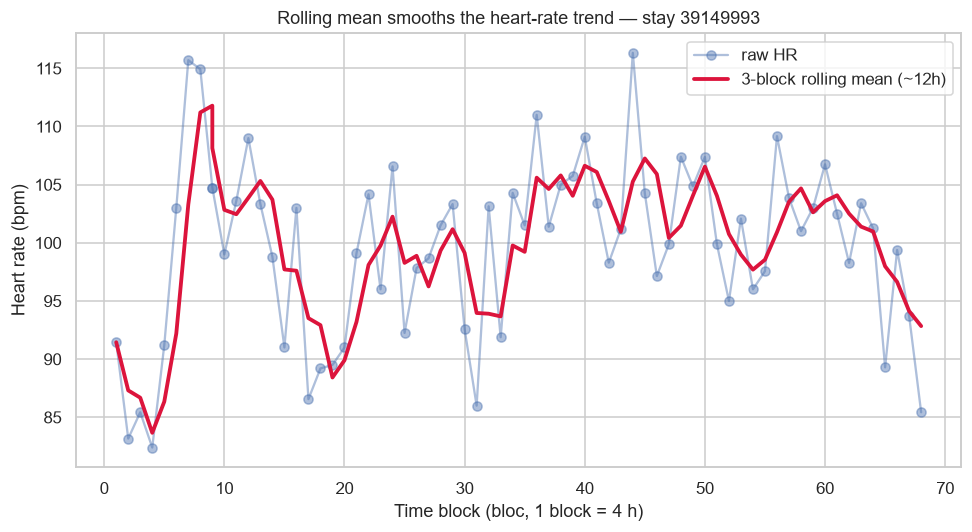

In [32]:
df["HR_roll3"] = (df.groupby("icustayid")["HR"]
                    .rolling(window=3, min_periods=1).mean()
                    .reset_index(level=0, drop=True))     # drop the group level so it realigns

pid = df["icustayid"].value_counts().index[0]             # a patient with a long stay
p = df[df["icustayid"] == pid]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p["bloc"], p["HR"], marker="o", alpha=0.45, label="raw HR")
ax.plot(p["bloc"], p["HR_roll3"], color="crimson", lw=2.5, label="3-block rolling mean (~12h)")
ax.set(title=f"Rolling mean smooths the heart-rate trend — stay {pid}",
       xlabel="Time block (bloc, 1 block = 4 h)", ylabel="Heart rate (bpm)")
ax.legend(); plt.tight_layout(); plt.show()

*Interpretation:* the crimson line strips out the block-to-block jitter and shows where the
patient's heart rate is genuinely trending.

### 28 · `.cumsum()` — running totals, per patient

Cumulative urine output over the stay — the running sum of `output_step`. `cumsum`/`cummax` respect the
timeline (they only ever add the past).

In [33]:
df["urine_cum"] = df.groupby("icustayid")["output_step"].cumsum()
one = df[df["icustayid"] == df["icustayid"].iloc[0]]
one[["icustayid", "bloc", "output_step", "urine_cum", "cumulated_balance"]].head(8)

,icustayid,bloc,output_step,urine_cum,cumulated_balance
0,30003226,1,65.0,65.0,2116.67
1,30003226,2,65.0,130.0,2252.59
2,30003226,3,80.0,210.0,2373.51
3,30003226,4,35.0,245.0,2549.43
4,30003226,5,62.0,307.0,2688.35
5,30003226,6,40.0,347.0,2920.54
6,30003226,7,64.0,411.0,3224.61
7,30003226,8,60.0,471.0,3374.41


> 🧠 **Clinical takeaway:** `shift`/`diff`/`rolling`/`cumsum` **grouped by `icustayid`** are the whole
> toolkit for turning a timeline into early-warning features — and grouping is what keeps one patient's
> data from leaking into another's. (Notebook 04 goes deep on this.)

### ✏️ Your turn #3
Add a **running count of hypotensive blocks** (`MeanBP < 65`) per patient using `groupby` + `cumsum`,
then show `icustayid, bloc, MeanBP, hypo_count` for the first patient.

In [34]:
# TODO: make a boolean (df["MeanBP"] < 65), convert to int, then groupby("icustayid").cumsum()


<details><summary>💡 Show solution</summary>

```python
df["hypo_count"] = (df["MeanBP"] < 65).astype(int).groupby(df["icustayid"]).cumsum()
first_id = df["icustayid"].iloc[0]
df.loc[df["icustayid"] == first_id, ["icustayid", "bloc", "MeanBP", "hypo_count"]].head(8)
```
</details>

---
## ⚡ Theme 6 — Performance & presentation (tricks 29–30)

### 29 · `.memory_usage()` + downcasting — shrink big tables

`float64`/`int64` are often overkill. Downcasting to 32-bit halves the memory with no meaningful loss of
precision for clinical vitals — the difference between a table that fits in Colab RAM and one that doesn't.

In [35]:
before = df.memory_usage(deep=True).sum() / 1e6

small = df.copy()
for c in small.select_dtypes("float64").columns:
    small[c] = pd.to_numeric(small[c], downcast="float")
for c in small.select_dtypes("integer").columns:
    small[c] = pd.to_numeric(small[c], downcast="integer")

after = small.memory_usage(deep=True).sum() / 1e6
print(f"before : {before:6.2f} MB")
print(f"after  : {after:6.2f} MB   ({100*(1-after/before):.0f}% smaller)")

before :  17.53 MB
after  :   8.07 MB   (54% smaller)


### 30 · `.style` — a colour-graded table for reports

`.style.background_gradient()` turns a plain summary into a heat-shaded table you can drop straight into
a slide. Here: mean vitals & severity by time-block.

In [36]:
tbl = (df.groupby("bloc")[["HR", "MeanBP", "Arterial_lactate", "SOFA"]]
         .mean().head(10))
(tbl.style
    .background_gradient(cmap="Reds")
    .format("{:.1f}")
    .set_caption("Mean vitals & severity by time-block (darker = higher)"))

,HR,MeanBP,Arterial_lactate,SOFA
bloc,,,,
1,86.5,82.8,2.0,4.5
2,84.5,80.0,2.0,4.5
3,83.7,79.6,2.0,4.5
4,83.3,79.8,1.9,4.4
5,83.3,79.7,1.9,4.3
6,83.3,79.6,1.8,4.3
7,83.0,79.2,1.8,4.3
8,82.9,79.6,1.8,4.4
9,83.0,79.8,1.7,4.4


> 🧠 **Clinical takeaway:** a styled table communicates a trend to non-technical colleagues faster
> than any raw dump — worth the one extra line.

## 🤖 Bonus — LLMs (ChatGPT / Claude) as your research copilot

Large language models are a genuine accelerator for medical scientists: they write pandas / scikit-learn
code, explain cryptic errors, draft plots, and translate statistics into plain language. Used well they save
hours; used carelessly they invent bugs and leak data. Here's how to use them **well**.

### 🔒 The one rule you must never break
**Never paste patient-level data (PHI) into a public LLM.** Individual rows — ages, dates, free-text notes —
can identify people and usually violate your data-use agreement and ethics approval. **Aggregate** statistics
(means, counts, a `describe()` table) and **schema** (column names, dtypes) are normally safe to share — but
check your institution's policy and your DUA first. When in doubt, don't.

### 📋 Prompt recipes that actually help
- **Explain an error** — *"I got this Python error; here's the traceback and the 5 lines around it. What's
  wrong and how do I fix it?"*
- **Write a transform** — *"Using pandas, give me a groupby on `icustayid` that computes each patient's max
  SOFA and last lactate."*
- **Draft a pipeline** — *"Write a scikit-learn Pipeline that median-imputes, scales, and fits logistic
  regression, scored with 5-fold ROC-AUC."*
- **Refactor / speed up** — *"Vectorise this loop over patients."*
- **Explain in plain language** — *"Explain a calibration curve to a clinician in three sentences."*
- **Generate a plot** — *"matplotlib code for a survivors-vs-non-survivors KDE of a column, fully labelled."*

### 🧪 Verify, always
LLM code is confidently wrong surprisingly often. Before you trust it: **run it on a small sample**, check
`df.shape` and dtypes didn't change unexpectedly, sanity-check the numbers against something you already know,
and never let generated code touch your only copy of the data. Treat the LLM as a fast junior colleague whose
work you always review.

In [37]:
# The kind of *aggregate* summary you CAN safely share with an LLM —
# no individual patients, just distributions and column names.
safe_to_share = patients[["age", "SOFA_max", "Arterial_lactate_max",
                          "Creatinine_max", "MeanBP_min", "morta_90"]].describe().T.round(2)
safe_to_share

,count,mean,std,min,25%,50%,75%,max
age,1696.0,65.63,16.28,18.00,56.00,67.00,78.00,98.00
SOFA_max,1696.0,7.16,2.85,0.00,5.00,7.00,9.00,17.00
Arterial_lactate_max,1696.0,3.46,1.63,0.58,2.22,3.06,4.28,7.05
Creatinine_max,1696.0,2.64,2.68,0.30,1.00,1.50,3.10,12.44
MeanBP_min,1696.0,67.95,11.00,23.00,60.75,66.68,74.33,116.75
morta_90,1696.0,0.18,0.39,0.00,0.00,0.00,0.00,1.00


> ### 🧠 Takeaway
> LLMs are a superb **copilot** for the pandas / scikit-learn work in this course — boilerplate, debugging,
> explanation. They are **not** a substitute for understanding your data or for careful validation, and they
> must **never** see identifiable patient data. Keep a human — you — in the loop.

---
## ✅ Recap

You now have **30 pandas moves** in your back pocket:

- **Select & filter:** `.loc`/`.iloc`, `.query`, `.isin`, `.between`, boolean masks, `.nlargest`, `.sample`
- **Transform:** `.assign`, `.pipe`, `.map`/`.replace`, `.clip`, `pd.cut`, `pd.qcut`, `.rank`
- **Summarise:** `.value_counts(normalize=True)`, `.nunique`, `pd.crosstab`, `.duplicated`,
  `groupby().agg` (named), `groupby().transform`
- **Reshape & combine:** `pivot_table`, `.melt`, `.merge`/`.join`, `.explode`
- **Time series (per-patient):** `.dt`, `.shift`/`.diff`, `.rolling`, `.cumsum`
- **Performance & polish:** `.memory_usage` + downcasting, `.style`

Each of these replaces a loop or a tangle of brackets with one readable line — over a project, that's
**hours saved** and far fewer bugs.

## ➡️ Next

- **Notebook 01** — Pandas for clinical data (the gentle, guided version of these moves)
- **Notebook 04** — Time-series feature engineering (the `shift`/`rolling`/`cumsum` tricks, in depth and
  leakage-aware — the heart of the course)
- **Notebook 11** — Reinforcement Learning for sepsis treatment (advanced bonus): from *predicting* the outcome to *choosing* the treatment.
- Keep this notebook open as a **cheat-sheet** while you work on your own data. 🩺